# Classification Lab

**Primary goal:** Build intuition for classification with **logistic regression**, **decision trees**, **KNNs** and **Naive Bayes classifiers**, and evaluate models with **confusion matrix**, **precision/recall**, and **F1 score**.

## Part 0 — Visual Intuition (2D toy data)
See how **logistic regression** draws a linear boundary, while **trees/KNN/NB** can draw curved ones.

Sometimes the data is not as perfectly separated as in the lecture's example: we might need more complex models to accurately learn our data.

Accuracy (Tree):        0.775
Accuracy (Logistic):    0.808
Accuracy (KNN):         0.808
Accuracy (Naive Bayes): 0.8
Accuracy (Ensemble):    0.817


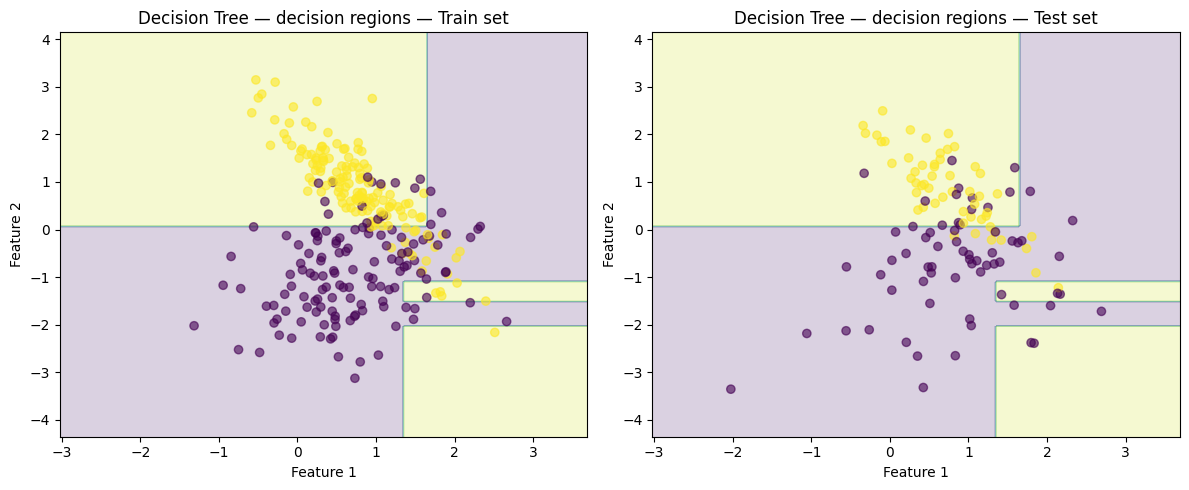

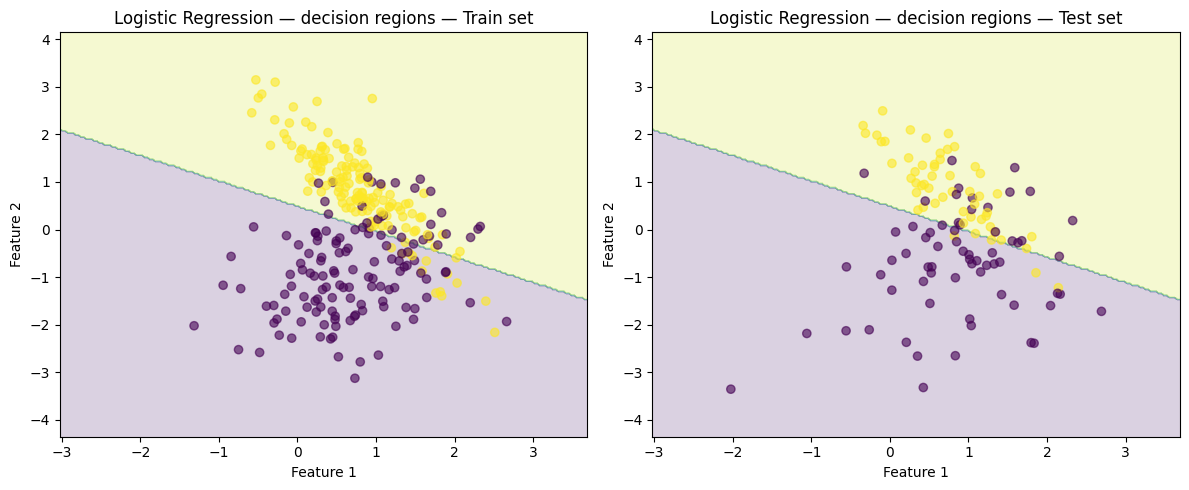

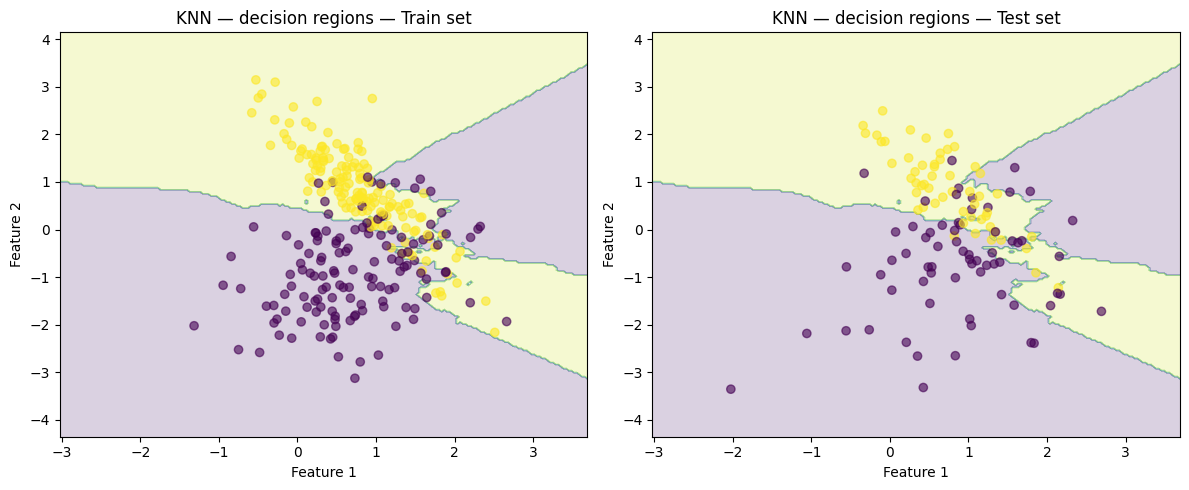

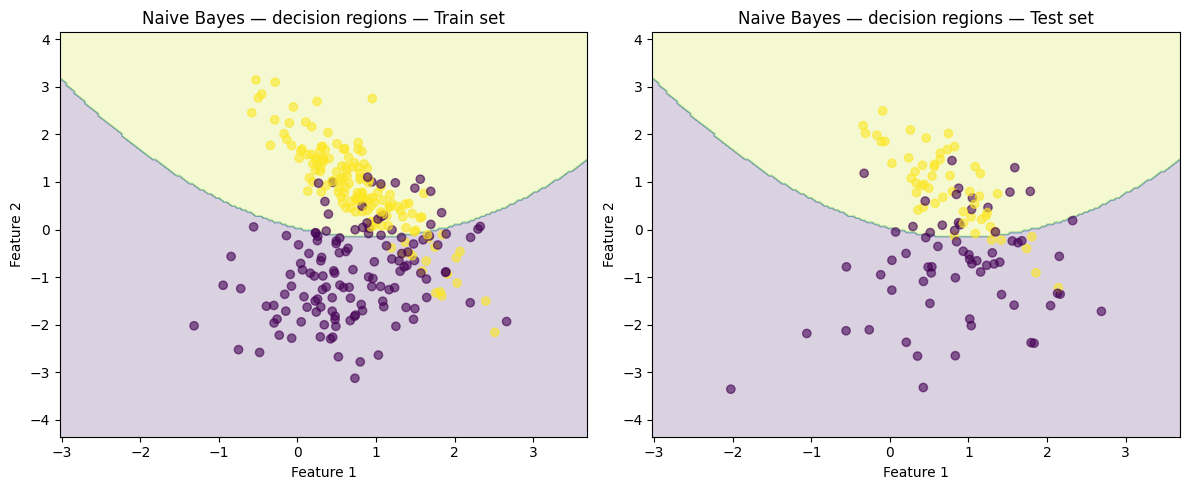

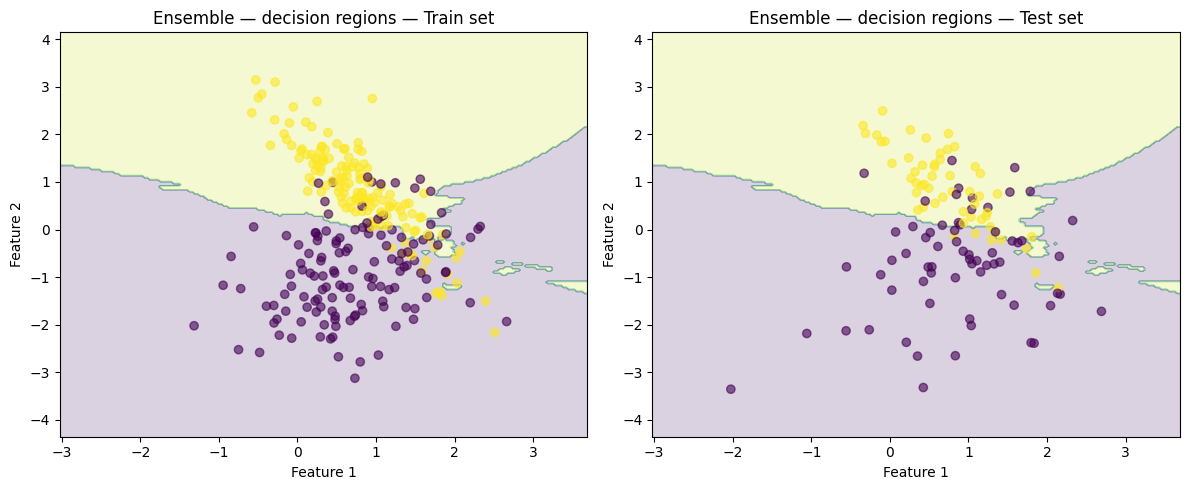

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

def ensemble_predict(X):
    """
    Predict class labels for input points using the ensemble of four models.

    Parameters
    ----------
    X : ndarray of shape (n_samples, n_features)
        Input features.

    Returns
    -------
    ensemble_pred : ndarray of shape (n_samples,)
        Predicted class labels (0 or 1) from the ensemble.
    """
    probs_logit = logit.predict_proba(X)[:, 1]
    probs_tree = tree.predict_proba(X)[:, 1]
    probs_knn = knn.predict_proba(X)[:, 1]
    probs_nb = nb.predict_proba(X)[:, 1]
    ensemble_probs = (probs_logit + probs_tree + probs_knn + probs_nb) / 4
    return (ensemble_probs >= 0.5).astype(int)

class EnsembleModel:
    def predict(self, X):
        return ensemble_predict(X)


# Create a 2D dataset
X, y = make_classification(n_samples=400, n_features=2, n_classes=2, n_redundant=0, n_clusters_per_class=1, class_sep=0.8, random_state=42) # Try to change the class_sep parameter: higher numbers make the problem easier, and vice-versa, so you can see how classifiers with different levels of complexity deal with easier or more difficult problems.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Models
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
logit = LogisticRegression()
knn = KNeighborsClassifier(n_neighbors=5)
nb = GaussianNB()
ensemble_model = EnsembleModel()

for model in [logit, tree, knn, nb]:
    model.fit(X_train, y_train)

ensemble_pred = ensemble_predict(X_test)

print("Accuracy (Tree):       ", round(float(accuracy_score(y_test, tree.predict(X_test))), 3))
print("Accuracy (Logistic):   ", round(float(accuracy_score(y_test, logit.predict(X_test))), 3))
print("Accuracy (KNN):        ", round(float(accuracy_score(y_test, knn.predict(X_test))), 3))
print("Accuracy (Naive Bayes):", round(float(accuracy_score(y_test, nb.predict(X_test))), 3))

print("Accuracy (Ensemble):   ", round(float(accuracy_score(y_test, ensemble_pred)), 3))

def plot_boundary_subplots(model, X_train, y_train, X_test, y_test, title):
    """
    Plot decision boundaries for a classifier on both training and test sets.

    This function visualizes the decision regions learned by a 2D classifier
    and overlays the training and test points in separate subplots.

    Parameters
    ----------
    model : estimator object
        A trained classifier with a `predict()` method.
    X_train : ndarray of shape (n_train_samples, 2)
        Training features (must have two columns for visualization).
    y_train : ndarray of shape (n_train_samples,)
        Training labels.
    X_test : ndarray of shape (n_test_samples, 2)
        Test features (two columns).
    y_test : ndarray of shape (n_test_samples,)
        Test labels.
    title : str
        Title prefix for the subplots.

    Returns
    -------
    None
        Displays two subplots (train/test) with decision regions and points.
    """
    
    x_min = min(X_train[:,0].min(), X_test[:,0].min()) - 1
    x_max = max(X_train[:,0].max(), X_test[:,0].max()) + 1
    y_min = min(X_train[:,1].min(), X_test[:,1].min()) - 1
    y_max = max(X_train[:,1].max(), X_test[:,1].max()) + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, X, y, label in zip(axes, [X_train, X_test], [y_train, y_test], ["Train", "Test"]):
        ax.contourf(xx, yy, Z, alpha=0.2)
        scatter = ax.scatter(X[:,0], X[:,1], c=y, alpha=0.6)
        ax.set_title(f"{title} — {label} set")
        ax.set_xlabel("Feature 1")
        ax.set_ylabel("Feature 2")
    plt.tight_layout()
    plt.show()

plot_boundary_subplots(tree,  X_train, y_train, X_test, y_test, "Decision Tree — decision regions")
plot_boundary_subplots(logit, X_train, y_train, X_test, y_test, "Logistic Regression — decision regions")
plot_boundary_subplots(knn,    X_train, y_train, X_test, y_test, "KNN — decision regions")
plot_boundary_subplots(nb,     X_train, y_train, X_test, y_test, "Naive Bayes — decision regions")
plot_boundary_subplots(ensemble_model, X_train, y_train, X_test, y_test, "Ensemble — decision regions")

## Part A — Quick Preprocessing (no work for you to do here!)
Load **Titanic** from a local CSV at `data/titanic.csv`.
It then initializes pipelines to preprocess the numeric and categorical features in a repeatable way, and splits the data in training and test data.

![Titanic](pics2/titanic-dont-worry-meme.jpg)

### Titanic Dataset — Feature Descriptions

The dataset contains information about passengers aboard the RMS Titanic.  
Each row represents one passenger, and the goal is to predict whether they **survived** or **did not survive**.

| Column | Description | Type |
|:--------|:-------------|:------:|
| **Survived** | Target variable — passenger survival status (`1` = survived, `0` = did not survive). | Categorical |
| **Pclass** | Passenger class — a proxy for socioeconomic status (`1` = 1st, `2` = 2nd, `3` = 3rd class). | Categorical (ordinal) |
| **Sex** | Biological sex of the passenger (`male` or `female`). | Categorical |
| **Age** | Age of the passenger in years (some values may be missing). | Numeric |
| **SibSp** | Number of siblings and/or spouses aboard the Titanic. | Numeric |
| **Parch** | Number of parents and/or children aboard the Titanic. | Numeric |
| **Fare** | Ticket fare paid by the passenger (in British pounds). | Numeric |
| **Embarked** | Port of embarkation — where the passenger boarded (`C` = Cherbourg, `Q` = Queenstown, `S` = Southampton). | Categorical |

**Note:**  
Categorical variables will be **one-hot encoded**, and numeric variables will be **scaled** before training the models.

**Question:**  
Do you have any ideas which variables might be more important than others, without looking at any plots?

![Titanic Ship](pics2/titanic-jack-and-rose-door.jpg)

In [2]:
# General imports
import pandas as pd, numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt

# Load Titanic dataset
df = pd.read_csv("data/titanic.csv")

target = 'Survived'
columns_to_keep = [c for c in ['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked'] if c in df.columns]
features = columns_to_keep

X = df[features].copy(); y = df[target].copy()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

numeric = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", MinMaxScaler())])
categorical = Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", ))])
preprocess = ColumnTransformer([("num", numeric, num_cols), ("cat", categorical, cat_cols)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train/Test:", X_train.shape, X_test.shape, " | Target positive rate:", float(y.mean()))

Train/Test: (712, 7) (179, 7)  | Target positive rate: 0.3838383838383838


## Part B — Baseline: Logistic Regression
Compute accuracy, confusion matrix, precision/recall, and **ROC–AUC**.

Accuracy: 0.793
Precision/Recall/F1: 0.767 0.667 0.713


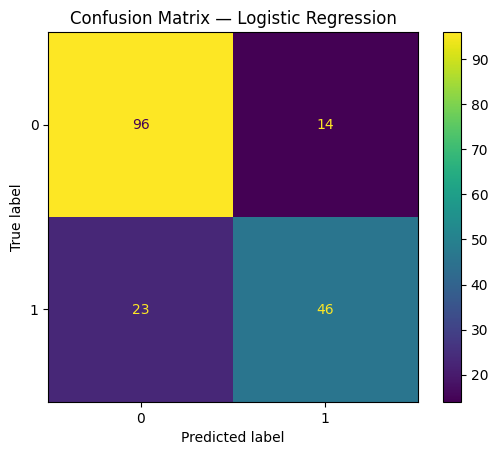

In [3]:
# Logistic regression imports
from sklearn.linear_model import LogisticRegression

# Using the preprocessing pipeline from above, create another pipeline including logistic regression.
lr = Pipeline([("preprocess", preprocess), ("model", LogisticRegression(max_iter=1000))])
# Fit the pipeline on the correct data (which data?)
lr.fit(X_train, y_train)
# Use the pipeline to make predictions on the correct data
y_pred = lr.predict(X_test)

# using the predictions, compute accuracy, precision, recall, and F1 score
acc_lr, prec_lr, rec_lr, f1_lr = accuracy_score(y_test, y_pred), precision_score(y_test, y_pred), recall_score(y_test, y_pred), f1_score(y_test, y_pred)
print("Accuracy:", round(float(acc_lr), 3))
print("Precision/Recall/F1:", 
    round(float(prec_lr), 3), 
    round(float(rec_lr), 3), 
    round(float(f1_lr), 3))

# Create and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix — Logistic Regression"); plt.show()

## Part C — Regularization (L2 vs L1) & Coefficients
Compare **L2** and **L1** penalties and inspect coefficients.

Base -> acc: 0.793  precision: 0.767  recall: 0.667  f1: 0.713
L1   -> acc: 0.782  precision: 0.742  recall: 0.667  f1: 0.702
L2   -> acc: 0.777  precision: 0.738  recall: 0.652  f1: 0.692


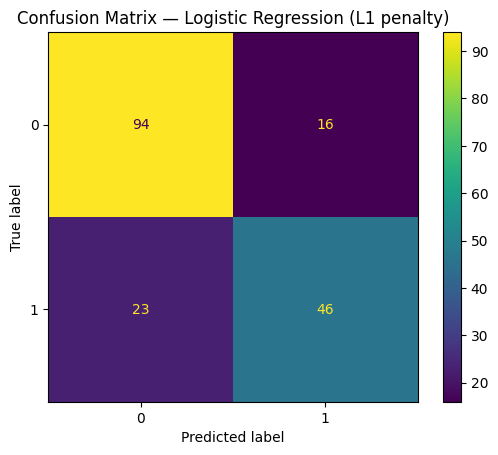

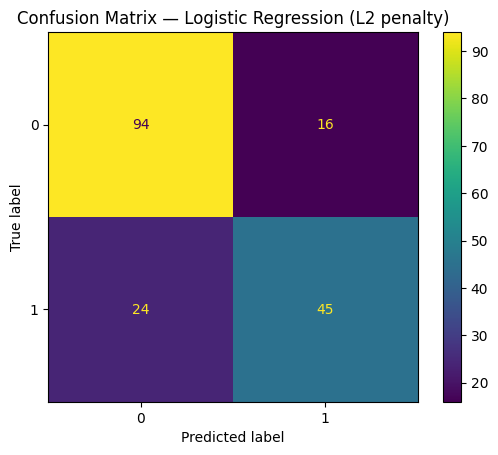

,feature,coef_base,coef_L1,coef_L2
0,Pclass,-2.029719,-1.947944,-1.223348
1,Age,-2.003512,-1.513558,-0.447408
5,Sex_female,1.280857,2.516717,1.061973
6,Sex_male,-1.280698,0.000000,-1.062142
2,SibSp,-0.985284,-0.338062,-0.194930
4,Fare,0.431710,0.000000,0.183266
3,Parch,-0.376979,0.000000,-0.072139
9,Embarked_S,-0.359814,-0.055048,-0.289658
8,Embarked_Q,0.267659,0.363527,0.090175
7,Embarked_C,0.092314,0.340382,0.199314


In [4]:
# Since we are going to fit multiple models, we create a function to write less code.
# This also makes the code easier to read, and to maintain.

# Create a function to fit and evaluate logistic regression models with different penalties.
# Keep in mind that not all solvers support all penalties: Check the documentation:
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression

# Remember to use the same preprocessing pipeline as above.
def fit(penalty, C=1.0, solver=None):
    """
    Train and evaluate a logistic regression model with specified regularization.

    Builds a scikit-learn `Pipeline` combining preprocessing and a
    `LogisticRegression` classifier, fits it on the training set, and evaluates
    performance on the test set using standard classification metrics.

    Parameters
    ----------
    penalty : {'l1', 'l2'}
        Type of regularization to use. `'l1'` applies Lasso (sparse weights);
        `'l2'` applies Ridge (shrinkage) regularization.
    C : float, default=1.0
        Inverse of regularization strength. Smaller values specify stronger
        regularization.
    solver : str or None, optional
        Optimization algorithm to use. If None, `'liblinear'` is selected for
        `'l1'` and `'lbfgs'` for `'l2'`.

    Returns
    -------
    model : sklearn.pipeline.Pipeline
        Fitted pipeline combining preprocessing and logistic regression.
    accuracy : float
        Classification accuracy on the test set.
    precision : float
        Precision on the test set.
    recall : float
        Recall on the test set.
    f1 : float
        F1 score on the test set.
    """

    # First, address the solver choice based on penalty if not provided
    if solver is None:
        solver = "liblinear" if penalty=="l1" else "lbfgs"
    # create your model as above
    model = Pipeline([("preprocess", preprocess), ("model", LogisticRegression(penalty=penalty, C=C, solver=solver, max_iter=2000))])
    # fit the model on the correct data
    model.fit(X_train, y_train)
    # use the model to create predictions
    y_hat = model.predict(X_test)
    # compute and return accuracy, precision, recall, and F1 score
    accuracy = accuracy_score(y_test, y_hat)
    precision = precision_score(y_test, y_hat)
    recall = recall_score(y_test, y_hat)
    f1 = f1_score(y_test, y_hat)
    # Also return the model, it will be useful later
    return model, accuracy, precision, recall, f1

lr_l1, acc_lr_l1, prec_lr_l1, rec_lr_l1, f1_lr_l1 = fit("l1", C=0.5, solver="liblinear")
lr_l2, acc_lr_l2, prec_lr_l2, rec_lr_l2, f1_lr_l2 = fit("l2", C=0.1)

print("Base -> acc:", f"{acc_lr:.3f}", " precision:", f"{prec_lr:.3f}", " recall:", f"{rec_lr:.3f}", " f1:", f"{f1_lr:.3f}")
print("L1   -> acc:", f"{acc_lr_l1:.3f}", " precision:", f"{prec_lr_l1:.3f}", " recall:", f"{rec_lr_l1:.3f}", " f1:", f"{f1_lr_l1:.3f}")
print("L2   -> acc:", f"{acc_lr_l2:.3f}", " precision:", f"{prec_lr_l2:.3f}", " recall:", f"{rec_lr_l2:.3f}", " f1:", f"{f1_lr_l2:.3f}")

# Feature names. This is premade, since a lot of it depends on my previous choices, in the preprocessing pipeline, but try to go through it and understand it.
def feat_names(pre, X):
    """
    Extract full feature names after preprocessing.

    Retrieves the output feature names from a scikit-learn `ColumnTransformer`
    that combines numeric and categorical preprocessing pipelines. This allows
    matching model coefficients or feature importances back to their original
    feature names after transformation (e.g., after one-hot encoding).

    Parameters
    ----------
    pre : sklearn.compose.ColumnTransformer
        Fitted `ColumnTransformer` containing numeric and categorical pipelines.
        The numeric pipeline must include an `impute` step, and the categorical
        pipeline must include a `onehot` step.
    X : pandas.DataFrame or ndarray
        Original input data before preprocessing. Used to align feature names.

    Returns
    -------
    list of str
        Full list of feature names after preprocessing, including expanded
        one-hot encoded categorical features.
    """

    num_names = pre.named_transformers_["num"].named_steps["impute"].get_feature_names_out(pre.transformers_[0][2])
    cat_enc = pre.named_transformers_["cat"].named_steps["onehot"]
    cat_names = cat_enc.get_feature_names_out(pre.transformers_[1][2]) if len(pre.transformers_[1][2])>0 else []
    return list(num_names) + list(cat_names)

names = feat_names(lr_l2.named_steps["preprocess"], X_train)
coefs_l2 = lr_l2.named_steps["model"].coef_.ravel()
coefs_l1 = lr_l1.named_steps["model"].coef_.ravel()
coefs_base = lr.named_steps["model"].coef_.ravel()

# As before, create confusion matrices for each model
for model, label in [(lr_l1, "L1 penalty"), (lr_l2, "L2 penalty")]:
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm).plot()
    plt.title(f"Confusion Matrix — Logistic Regression ({label})")
    plt.show()

# Show the coefficients for each model
pd.DataFrame({
    "feature": names,
    "coef_base": coefs_base,
    "coef_L1": coefs_l1,
    "coef_L2": coefs_l2
}).sort_values(by="coef_base", key=lambda s: s.abs(), ascending=False).head(20)

## Part D — Decision Trees, Naive Bayes, KNN
Compare **DecisionTreeClassifier**, .

Tree -> acc: 0.793  precision: 0.864  recall: 0.551  f1: 0.673


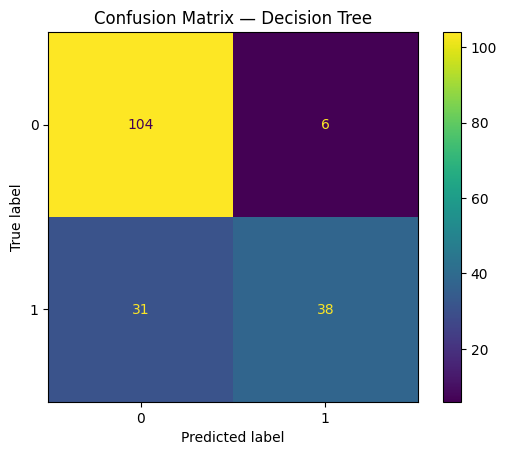

,feature,importance
5,Sex_female,0.576297
0,Pclass,0.195920
1,Age,0.114526
4,Fare,0.063141
9,Embarked_S,0.037198
2,SibSp,0.012109
3,Parch,0.000809
6,Sex_male,0.000000
7,Embarked_C,0.000000
8,Embarked_Q,0.000000


In [5]:
# Decision tree imports
from sklearn.tree import DecisionTreeClassifier

# Fit a decision tree using the same preprocessing pipeline as before
tree = Pipeline([("preprocess", preprocess), ("model", DecisionTreeClassifier(max_depth=4, random_state=42))]).fit(X_train, y_train)
# Make predictions
y_hat_tree = tree.predict(X_test)
# Evaluate performance
acc_tree = accuracy_score(y_test, y_hat_tree)
prec_tree = precision_score(y_test, y_hat_tree)
rec_tree = recall_score(y_test, y_hat_tree)
f1_tree = f1_score(y_test, y_hat_tree)

print("Tree -> acc:", f"{acc_tree:.3f}", " precision:", f"{prec_tree:.3f}", " recall:", f"{rec_tree:.3f}", " f1:", f"{f1_tree:.3f}")
# Create and plot the confusion matrix for the decision tree
cm = confusion_matrix(y_test, y_hat_tree)
ConfusionMatrixDisplay(cm).plot()
plt.title(f"Confusion Matrix — Decision Tree")
plt.show()
# Show feature importances from the decision tree. You can reuse the feat_names function from before, and DTs have a nice attribute to get them.
importances = tree.named_steps["model"].feature_importances_
names = feat_names(tree.named_steps["preprocess"], X_train)
pd.DataFrame({"feature": names, "importance": importances}).sort_values(by="importance", ascending=False).head(10)

Naive Bayes -> acc: 0.782  precision: 0.742  recall: 0.667  f1: 0.702


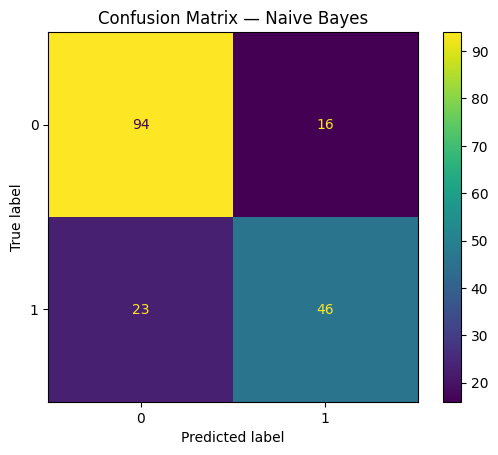

In [6]:
from sklearn.naive_bayes import MultinomialNB

# Different classifier, same preprocessing pipeline as before
nb = Pipeline([("preprocess", preprocess), ("model", MultinomialNB(alpha=1.0))]).fit(X_train, y_train)
# same steps as before
y_hat_nb = nb.predict(X_test)
# compute and print metrics
acc_nb = accuracy_score(y_test, y_hat_nb)
prec_nb = precision_score(y_test, y_hat_nb)
rec_nb = recall_score(y_test, y_hat_nb)
f1_nb = f1_score(y_test, y_hat_nb)

print("Naive Bayes -> acc:", f"{acc_nb:.3f}", " precision:", f"{prec_nb:.3f}", " recall:", f"{rec_nb:.3f}", " f1:", f"{f1_nb:.3f}")
# Create and plot the confusion matrix for Naive Bayes
cm = confusion_matrix(y_test, y_hat_nb)
ConfusionMatrixDisplay(cm).plot()
plt.title(f"Confusion Matrix — Naive Bayes")
plt.show()


KNN -> acc: 0.804  precision: 0.804  recall: 0.652  f1: 0.720


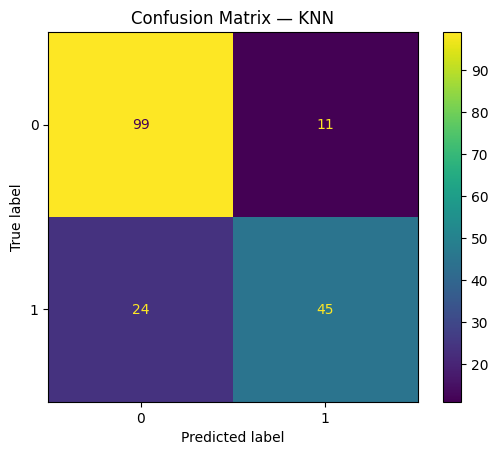

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import pairwise_distances
# We have categorical features and numerical features.
# Different kinds of distances are appropriate for different feature types.
# KNN is not ideal for mixed data, but we can still use it if we handle the distances in a smart way.
preprocessing_numeric = numeric.fit(X_train[num_cols])
preprocessing_categorical = categorical.fit(X_train[cat_cols])

preprocessed_numeric_train = preprocessing_numeric.transform(X_train[num_cols])
preprocessed_categorical_train = preprocessing_categorical.transform(X_train[cat_cols])
preprocessed_numeric_test = preprocessing_numeric.transform(X_test[num_cols])
preprocessed_categorical_test = preprocessing_categorical.transform(X_test[cat_cols])

# Convert sparse matrices to dense arrays for pairwise_distances
cat_train_dense = preprocessed_categorical_train.toarray()
cat_test_dense = preprocessed_categorical_test.toarray()

hamming_dist = pairwise_distances(cat_train_dense, metric='hamming')
euclidean_dist = pairwise_distances(preprocessed_numeric_train, metric='euclidean')
combined_dist = (hamming_dist * 4/7) + (euclidean_dist * 3/7) # weights based on number of features of each type

knn = KNeighborsClassifier(n_neighbors=5, metric='precomputed')
knn.fit(combined_dist, y_train)

test_hamming_dist = pairwise_distances(cat_test_dense, cat_train_dense, metric='hamming')
test_euclidean_dist = pairwise_distances(preprocessed_numeric_test, preprocessed_numeric_train, metric='euclidean')
test_combined_dist = (test_hamming_dist * 4/7) + (test_euclidean_dist * 3/7)

y_hat_knn = knn.predict(test_combined_dist)

acc_knn = accuracy_score(y_test, y_hat_knn)
prec_knn = precision_score(y_test, y_hat_knn)
rec_knn = recall_score(y_test, y_hat_knn)
f1_knn = f1_score(y_test, y_hat_knn)

print("KNN -> acc:", f"{acc_knn:.3f}", " precision:", f"{prec_knn:.3f}", " recall:", f"{rec_knn:.3f}", " f1:", f"{f1_knn:.3f}")

cm = confusion_matrix(y_test, y_hat_knn)
ConfusionMatrixDisplay(cm).plot()
plt.title(f"Confusion Matrix — KNN")
plt.show()

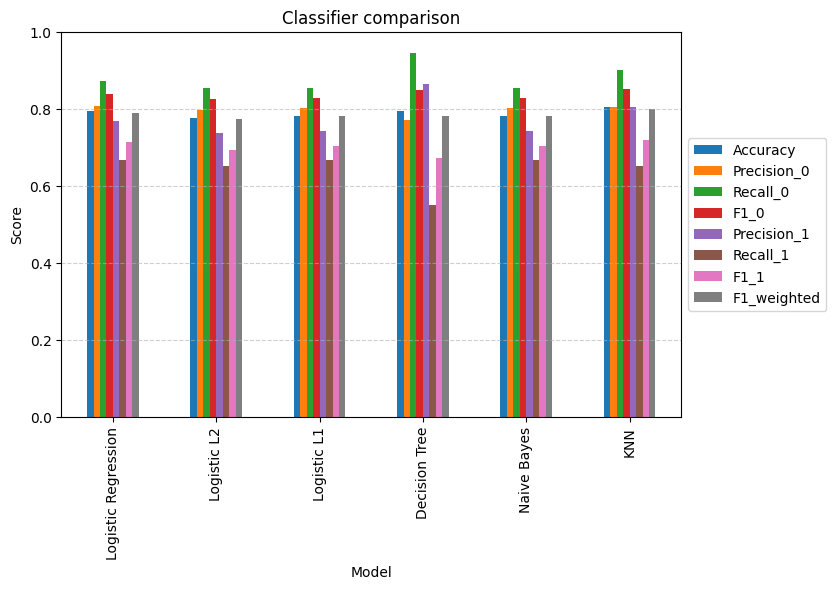

,Accuracy,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1,F1_weighted
Model,,,,,,,,
Logistic Regression,0.793,0.807,0.873,0.838,0.767,0.667,0.713,0.790
Logistic L2,0.777,0.797,0.855,0.825,0.738,0.652,0.692,0.774
Logistic L1,0.782,0.803,0.855,0.828,0.742,0.667,0.702,0.780
Decision Tree,0.793,0.770,0.945,0.849,0.864,0.551,0.673,0.781
Naive Bayes,0.782,0.803,0.855,0.828,0.742,0.667,0.702,0.780
KNN,0.804,0.805,0.900,0.850,0.804,0.652,0.720,0.800


In [8]:
from networkx import display
from sklearn.metrics import precision_recall_fscore_support
# It is now time to compare all our models, using a few metrics.
models = {
    "Logistic Regression": lr,
    "Logistic L2": lr_l2,
    "Logistic L1": lr_l1,
    "Decision Tree": tree,
    "Naive Bayes": nb,
    "KNN": knn
}

results = []

# for each model, compute accuracy, precision, recall, F1 for each class, and weighted F1
for name, model in models.items():
    if name == "KNN":
        y_pred = model.predict(test_combined_dist)
    else:
        y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None, labels=[0, 1])
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision_0": prec[0], "Recall_0": rec[0], "F1_0": f1[0],
        "Precision_1": prec[1], "Recall_1": rec[1], "F1_1": f1[1],
        "F1_weighted": f1_score(y_test, y_pred, average="weighted")
    })

# create a DataFrame from the results and display it
results_df = pd.DataFrame(results).set_index("Model").round(3)

# Create a simple bar plot to visually compare the results of the models.
ax = results_df.plot(kind="bar", figsize=(8,5))
plt.title("Classifier comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

results_df


## Wrap-up & Reflection
- Which model performed best, and why?  
- What trade-offs did you see between **interpretability** (logistic) and **more complex models**?